In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

Bonus proof to exercise in Lecture 4

In [2]:
# Calculating the number of legal terms (without considering graph equivalence) a graph is split into by collapsing legal combination of nodes

def a_total(n):
    return np.sum([a(n, k) for k in range(1, n+1)])

def a(n, k):
    if(n==k):
        return 1
    if(k==1): 
        # if n is not 1 (this case would be covered by the first base case), there is no way to collapse all field points into one field point without collapsing "illegal" combinations of neighbours 
        # - which are illegal because they give a hopping of 0
        return 0
    return ((k-1)*a(n-1, k) + a(n-1, k-1))

for i in range(1, 6):
    print(f"a({i}) is {a_total(i)}")

print("Contributions to a(4):")
for i in range(2, 5):
    print(f"a(4,{i}) is {a(4, i)}")

print("Contributions to a(5):")
for i in range(2, 6):
    print(f"a(5,{i}) is {a(5, i)}")


a(1) is 1
a(2) is 1
a(3) is 2
a(4) is 5
a(5) is 15
Contributions to a(4):
a(4,2) is 1
a(4,3) is 3
a(4,4) is 1
Contributions to a(5):
a(5,2) is 1
a(5,3) is 7
a(5,4) is 6
a(5,5) is 1


Exercise in Lecture 5

We solve the cubic equation for $x=G(z)$ by applying Cardano's formula (https://math.vanderbilt.edu/schectex/courses/cubic/). When starting with $ax^3+bx^2+cx+d = 0$, we use the substitution $x=y-\frac{b}{3a}$ to get the "depressed cubic": $y^3+py+qy$ with p being defined as: $p:=\frac{c}{a}-\frac{b^2}{3a^2}$ and q as: $\frac{2b^3}{27a^3}-\frac{bc}{3a^2}+\frac{d}{a}$.

The principal root of this equation is then $y = \sqrt[3]{-\frac{q}{2}+\sqrt{(\frac{q}{2})^2 + (\frac{p}{3})^3}} + \sqrt[3]{-\frac{q}{2}-\sqrt{(\frac{q}{2})^2 + (\frac{p}{3})^3}}$

This result is then "converted back" to get the solution for x: $x=y-\frac{b}{3a}$ to get the principal root.

Note that numpy.roots seems to not give the roots in a consistent order and in order to definetely stay on the correct and same root, this calculation is done manually with Cardano's formula.

In [ ]:
FERMI_LEVEL = 0

def solve_cubic_equation(a, b, c, d):
    p = (c/a) - ((b**2) / (3*(a**2)))
    q = ((2*(b**3))/(27*(a**3))) - ((b*c)/(3*(a**2))) + (d/a)

    term_sqrt = np.sqrt((q/2)**2 + (p/3)**3)

    y = (-(q/2)+term_sqrt)**(1/3) + (-(q/2)-term_sqrt)**(1/3)
    x = y - (b/(3*a))
    return -1/x # TODO this is scetchy


import numpy as np

def solve_cubic_equation_correct_cardano(a, b, c, d):
    # Wichtig: Alles explizit komplex rechnen (0j hinzufügen)
    a, b, c, d = map(lambda v: complex(v), [a, b, c, d])
    
    p = (c/a) - ((b**2) / (3*(a**2)))
    q = ((2*(b**3))/(27*(a**3))) - ((b*c)/(3*(a**2))) + (d/a)

    term_sqrt = np.sqrt((q/2)**2 + (p/3)**3 + 0j)

    # 1. Berechne u als komplexen Hauptwert
    u = (-(q/2) + term_sqrt) ** (1/3)
    
    # Falls u nahe 0 ist, nutzen wir das andere Vorzeichen für term_sqrt
    if np.isclose(u, 0):
        u = (-(q/2) - term_sqrt) ** (1/3)

    # 2. Erzwinge v über die mathematische Bedingung u * v = -p/3
    # Dadurch wählt Python automatisch den exakt passenden Zweig!
    if not np.isclose(u, 0):
        v = -p / (3 * u)
    else:
        v = 0.0

    # Das liefert jetzt eine der drei echten mathematischen Wurzeln!
    # Um alle 3 Wurzeln zu erhalten, multipliziert man mit dem Rotationsfaktor
    omega = np.exp(2j * np.pi / 3)
    
    x1 = (u + v) - (b / (3 * a))
    x2 = (u * omega + v * omega**2) - (b / (3 * a))
    x3 = (u * omega**2 + v * omega) - (b / (3 * a))
    
    # Gib alle drei exakt berechneten Wurzeln als Array zurück
    return np.array([x1, x2, x3])


def solve_for_G_cardano(Delta, x, omega):
    V_star = 1
    eta = 1e-4
    z = omega + 1j * eta  # eventuell plus i eta?
    a = V_star**4
    b = -2*z
    c = z**2 - Delta**2 + V_star**2
    d = -2*Delta*x - z + Delta
    G_principal_root = solve_cubic_equation(a, b, c, d)
    return G_principal_root

def solve_for_G_at_fermi_level_cardano(Delta, x):
    return solve_for_G_cardano(Delta, x, FERMI_LEVEL)

def DoS_fermi_level_cardano(Delta, x):
    G = solve_for_G_at_fermi_level_cardano(Delta, x)
    return -1.0 / np.pi * np.imag(G)

Other possibility with numpy

In [66]:
import numpy as np

FERMI_LEVEL = 0.0
ETA = 1e-5 

def solve_for_G_numpy(Delta, x, omega):
    V = 1
    eta = 1e-4
    z = omega + 1j * eta  # eventuell plus i eta?
    a = V**4
    b = -2*z
    c = z**2 - Delta**2 + V**2
    d = -2*Delta*x - z + Delta
    
    coefficients = [a, b, c, d]
    all_roots = np.roots(coefficients) # this is numerically more stable than other ways I have tried, e.g. Cardano's formula
    
    # PHYSIKALISCHES KRITERIUM: 
    # Für die retardierte Green-Funktion suchen wir die Wurzel mit dem NEGATIVSTEN Imaginärteil
    # (bzw. diejenige, die eine positive Zustandsdichte liefert).
    imag_parts = np.imag(all_roots)
    anzahl_negativ = np.sum(imag_parts < 0)
    if(anzahl_negativ > 1):
        print("Kriiiiise")
    G_principal = all_roots[np.argmin(imag_parts)] 
    
    return G_principal

def DoS_fermi_level_numpy(Delta, x):
    # DoS ist definiert als: -1/pi * Im(G)
    G = solve_for_G_numpy(Delta, x, FERMI_LEVEL)
    return -1.0 / np.pi * np.imag(G)

1.0


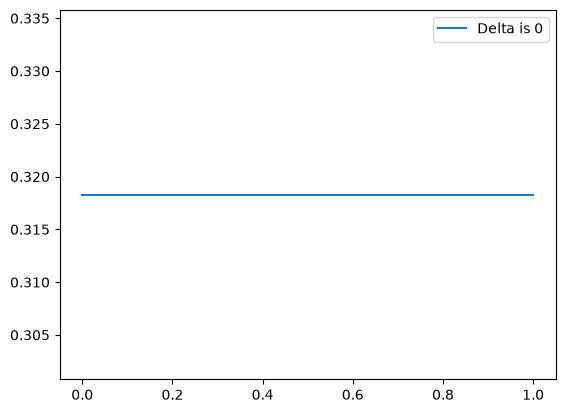

1.0


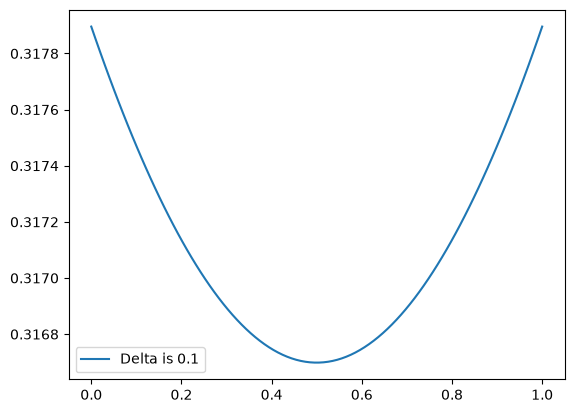

1.0


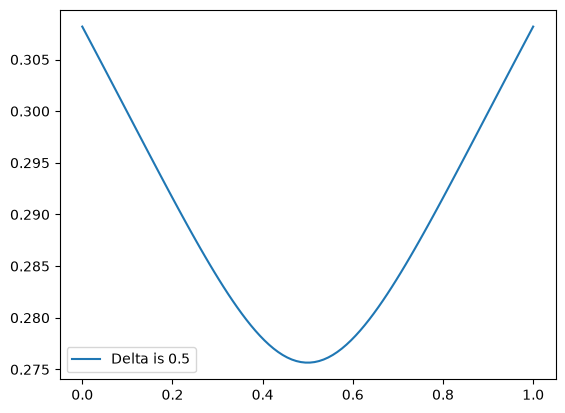

1.0


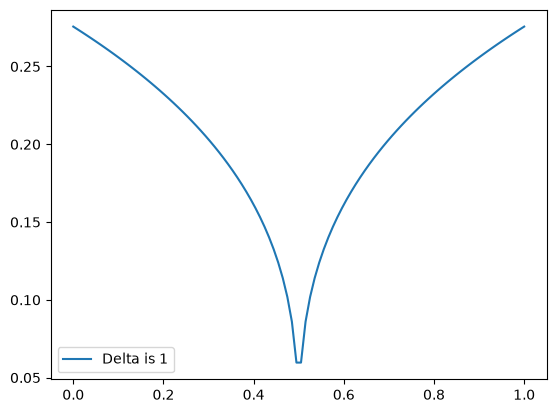

0.4747474747474748


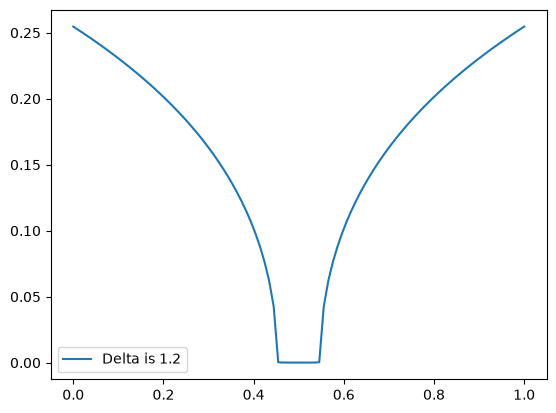

0.33333333333333337


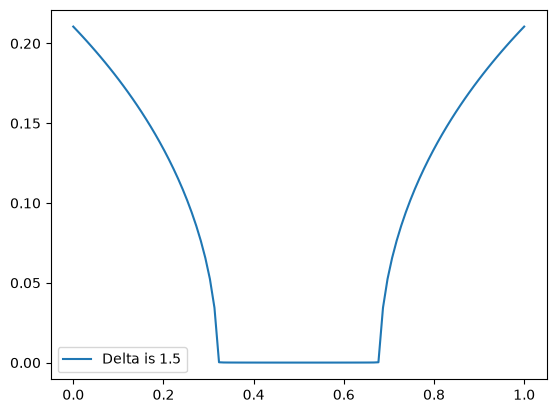

0.020202020202020204


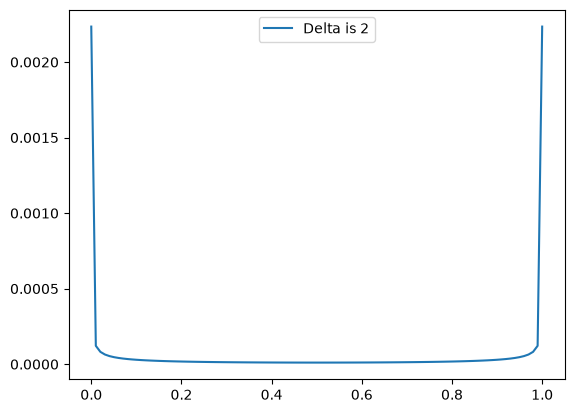

1.0


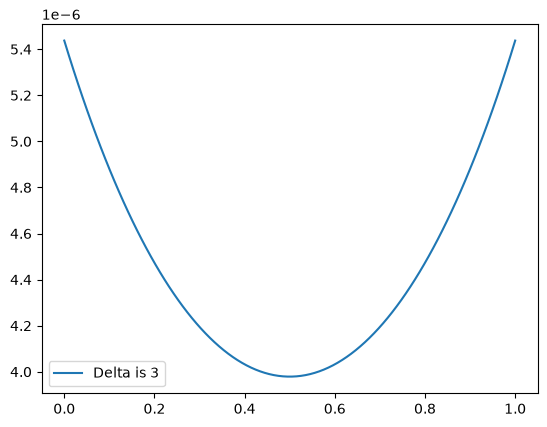

In [67]:
Deltas = [0, 0.1, 0.5, 1, 1.2, 1.5, 2, 3] # mit Energieeinheit abgleichen! TODO
# Delta << 1     weak disorder / small on-site contrast
# Delta ~ 1      moderate disorder
# Delta > 1–2    strong disorder, possible band splitting / gap opening

# TODO diskutieren: Ob ein Gap bei ω=0 entsteht, hängt aber nicht nur von Δ, sondern auch von K, V und x ab. Wenn dein ungestörtes Band etwa
# breit ist, dann muss Δ groß genug sein, um die zwei Bestandteile spektral deutlich zu trennen. Daher sind On-site-Energien der Größenordnung 0 bis ein paar V typische sinnvolle Werte.
xs = np.linspace(0.0, 1.0, 100)

for Delta in Deltas:
    print(find_critical_x(Delta))
    DoSs = []
    for x in xs:
        DoSs.append(DoS_fermi_level_numpy(Delta, x)) # TODO ausgeben lassen wenn DoS actually 0 ist
    plt.plot(xs, DoSs, label=f"Delta is {Delta}")
    plt.legend()
    plt.show()

/tmp/ipykernel_11288/280479854.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


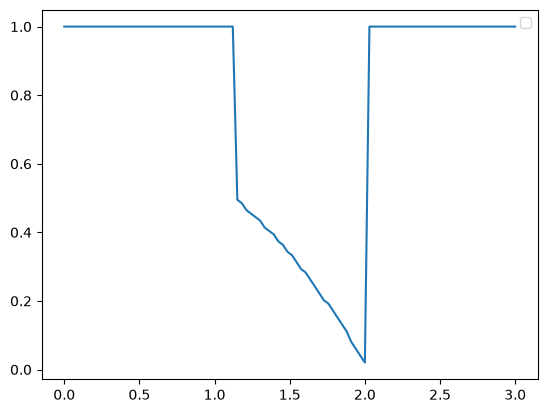

In [68]:
# Delta << 1     weak disorder / small on-site contrast
# Delta ~ 1      moderate disorder
# Delta > 1–2    strong disorder, possible band splitting / gap opening


def find_critical_x(Delta):
    eta = 1e-4
    xs = np.linspace(0.0, 1.0, 100)
    DoSs = []
    for x in xs:
        DoSs.append(DoS_fermi_level_numpy(Delta, x))
    previous_DoS = DoSs[0]
    for i in range(1, len(DoSs)-1):
        current_DoS = DoSs[i]
        if ((previous_DoS < -eta and current_DoS > -eta) or (previous_DoS > eta and current_DoS < eta)): # TODO anpassen je nachdem obs steigt oder fällt
            return xs[i]
        else:
            previous_DoS = current_DoS
    return 1.0

# TODO diskutieren: Ob ein Gap bei ω=0 entsteht, hängt aber nicht nur von Δ, sondern auch von K, V und x ab. Wenn dein ungestörtes Band etwa
# breit ist, dann muss Δ groß genug sein, um die zwei Bestandteile spektral deutlich zu trennen. Daher sind On-site-Energien der Größenordnung 0 bis ein paar V typische sinnvolle Werte.
Deltas = np.linspace(0.0, 3.0, 100)
x_crits = []

for Delta in Deltas:
    x_crits.append(find_critical_x(Delta))

plt.plot(Deltas, x_crits)
plt.legend()
plt.show()

In [65]:
omega = 10000
Delta = 1
x = 0.1
principal_root = solve_for_G_cardano(Delta, x, omega)
rotation = -0.5 + 3**(1/2)/2 *1j
root1 = principal_root * rotation
root2 = root1 * rotation
print(principal_root)
print(root1)
print(root2)
print(1/omega)

(-9.99900018995856e-05+9.9980005169306e-13j)
(4.999500008394056e-05-8.659388226939543e-05j)
(4.999500181564503e-05+8.659388126959537e-05j)
0.0001


In [ ]:
import numpy as np


# TODO machen die nächsten zwei Methoden Sinn?
def fixed_point_update(G, z, Delta, Vt, x):
    return (
        x / (z - Delta - Vt**2 * G)
        + (1 - x) / (z + Delta - Vt**2 * G)
    )

def solve_G_for_omega(z, Delta, Vt, x, G0, tol=1e-10, max_iter=10000, mix=0.5):
    G = G0

    for _ in range(max_iter):
        G_fp = fixed_point_update(G, z, Delta, Vt, x)

        # mixing makes the iteration more stable
        G_new = (1 - mix) * G + mix * G_fp

        if abs(G_new - G) < tol:
            return G_new

        G = G_new

    raise RuntimeError("Self-consistency did not converge")


def G_average_fermi_level(Delta, x):
    omega_max = 10.0 # TODO macht das Sinn?
    eta = 1e-3
    number_of_omegas = 1000
    omegas = np.linspace(omega_max, FERMI_LEVEL, number_of_omegas)
    Vt = 1.0

    results = []

    # initial value from asymptotics
    z0 = omegas[0] + 1j * eta
    G_previous = 1 / z0

    for omega in omegas:
        z = omega + 1j * eta
        G_current = solve_G_for_omega(z, Delta, Vt, x, G_previous)

        results.append(G_current)
        G_previous = G_current
    
    return results[-1]

def DoS_fermi_level(Delta, x):
    return G_average_fermi_level(Delta, x).imag

# oder imaginary part des roots soll kleiner 0 sein?! TODO wie roots auswählen

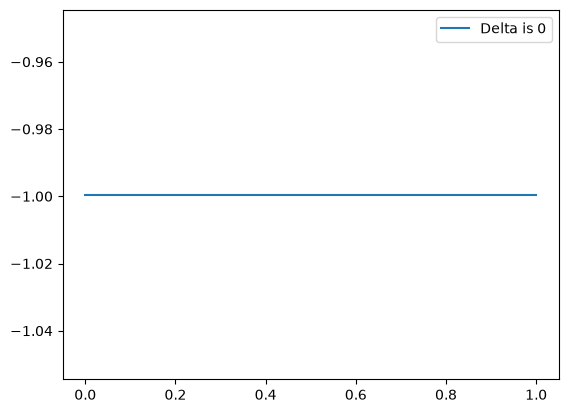

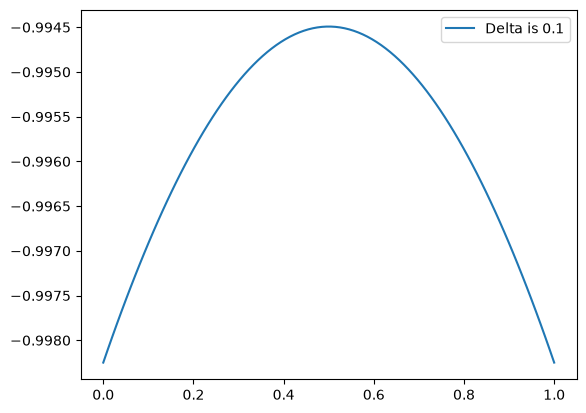

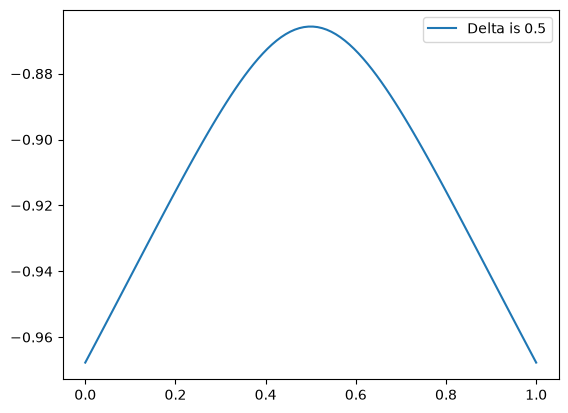

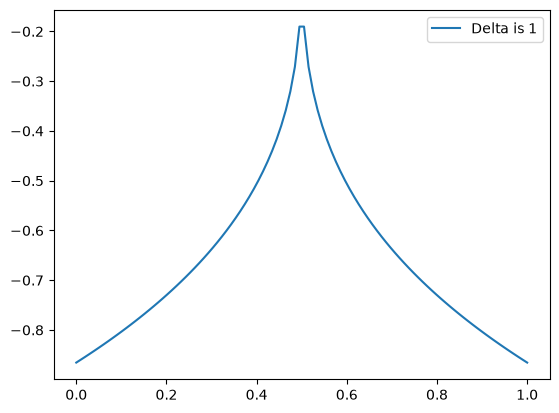

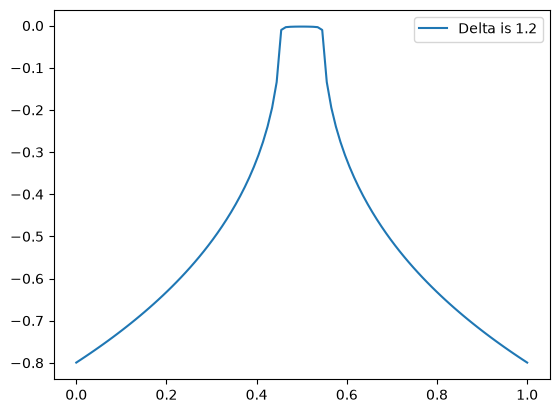

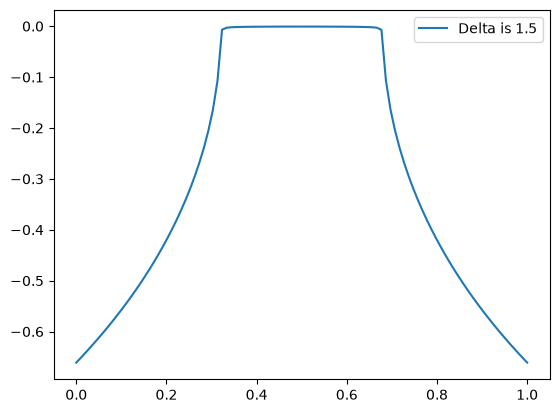

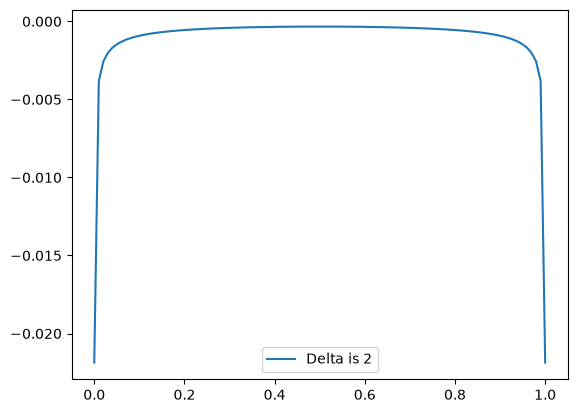

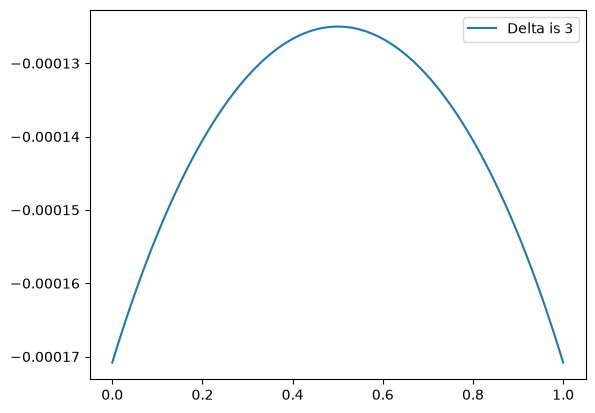

In [ ]:
Deltas = [0, 0.1, 0.5, 1, 1.2, 1.5, 2, 3] # mit Energieeinheit abgleichen! TODO
# Delta << 1     weak disorder / small on-site contrast
# Delta ~ 1      moderate disorder
# Delta > 1–2    strong disorder, possible band splitting / gap opening

# TODO diskutieren: Ob ein Gap bei ω=0 entsteht, hängt aber nicht nur von Δ, sondern auch von K, V und x ab. Wenn dein ungestörtes Band etwa
# breit ist, dann muss Δ groß genug sein, um die zwei Bestandteile spektral deutlich zu trennen. Daher sind On-site-Energien der Größenordnung 0 bis ein paar V typische sinnvolle Werte.
xs = np.linspace(0.0, 1.0, 100)

for Delta in Deltas:
    DoSs = []
    for x in xs:
        DoSs.append(DoS_fermi_level(Delta, x)) # TODO ausgeben lassen wenn DoS actually 0 ist
    plt.plot(xs, DoSs, label=f"Delta is {Delta}")
    plt.legend()
    plt.show()



Task 8e)

In [5]:
import numpy as np
from scipy.integrate import quad

def F(Delta):
    integrand = lambda y: np.sqrt(1-y**2) / np.sqrt(Delta**2 + 4*y**2)
    val, err = quad(integrand, 0, 1)
    return 4*Delta/np.pi * val

def parametric_solution(Delta_values):
    U_values = []
    mu_values = []

    for Delta in Delta_values:
        f = F(Delta)
        U = 2 * Delta / f
        mu = f 

        U_values.append(U)
        mu_values.append(mu)

    return np.array(U_values), np.array(mu_values)

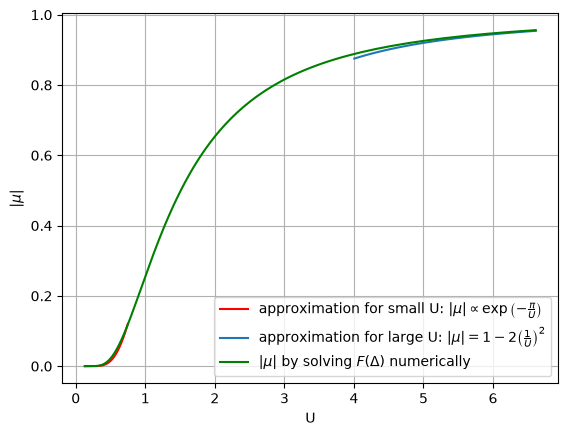

In [6]:
Delta_values = np.logspace(-10, 0.5, 800)

U_values, mu_values = parametric_solution(Delta_values)

small_mask = U_values <= 0.75
approx_small_U = 8 * np.exp(-np.pi / U_values[small_mask])

large_mask = U_values >= 4
approx_large_U = 1 - 2* (1/ U_values[large_mask])**2

label_exp = r"$|\mu| \propto \exp\left(-\frac{\pi}{U}\right)$"
label_large_U = r"$|\mu| = 1 - 2\left(\frac{1}{U}\right)^2$"
label_mu = r"$|\mu|$ by solving $F(\Delta)$ numerically"

plt.plot(U_values[small_mask], approx_small_U, color="red", label=f"approximation for small U: {label_exp}")
plt.plot(U_values[large_mask], approx_large_U, label=f"approximation for large U: {label_large_U}")

plt.plot(U_values, mu_values, label = label_mu, color="green")
plt.legend()
plt.xlabel("U")
plt.ylabel(r"$|\mu|$")
plt.grid(True)
plt.savefig("solving_for_mu")
plt.show()


Task 8f)

In [7]:
def calculate_D_A_up(omega, Delta):
    omega = np.asarray(omega)
    D = np.zeros_like(omega, dtype=float)

    edge = np.sqrt(Delta**2 + 4)

    # positiver Frequenzbereich: Delta <= omega <= sqrt(Delta^2 + 4)
    mask_pos = (omega >= Delta) & (omega <= edge)

    # negativer Frequenzbereich: -sqrt(Delta^2 + 4) <= omega <= -Delta
    # am Punkt omega = -Delta hat die Formel eine integrable Divergenz,
    # deshalb vermeiden wir exakt den Randpunkt.
    eps = 1e-14
    mask_neg = (omega >= -edge) & (omega <= -Delta - eps)

    D[mask_pos] = (
        1 / (2*np.pi)
        * np.sqrt((omega[mask_pos] - Delta) / (omega[mask_pos] + Delta))
        * np.sqrt(np.maximum(4 + Delta**2 - omega[mask_pos]**2, 0))
    )

    abs_omega = np.abs(omega[mask_neg])

    D[mask_neg] = (
        1 / (2*np.pi)
        * np.sqrt((abs_omega + Delta) / (abs_omega - Delta))
        * np.sqrt(np.maximum(4 + Delta**2 - omega[mask_neg]**2, 0))
    )

    return D

In [11]:
import pandas as pd

U_targets = np.array([0.5, 1, 4])

rows = []

for U_target in U_targets:
    idx = np.argmin(np.abs(U_values - U_target))

    rows.append({
        "U_target": U_target,
        "U_nearest": U_values[idx],
        "Delta": Delta_values[idx],
        "|mu|": mu_values[idx],
    })

df_U_values = pd.DataFrame(rows)
print(df_U_values)

   U_target  U_nearest     Delta      |mu|
0       0.5   0.500046  0.005499  0.021995
1       1.0   1.000552  0.127941  0.255740
2       4.0   4.005460  1.779561  0.888568


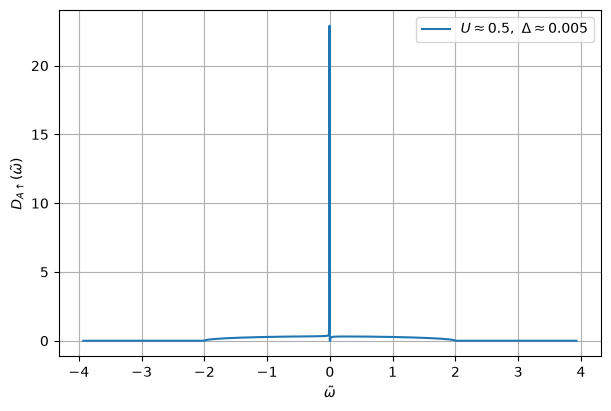

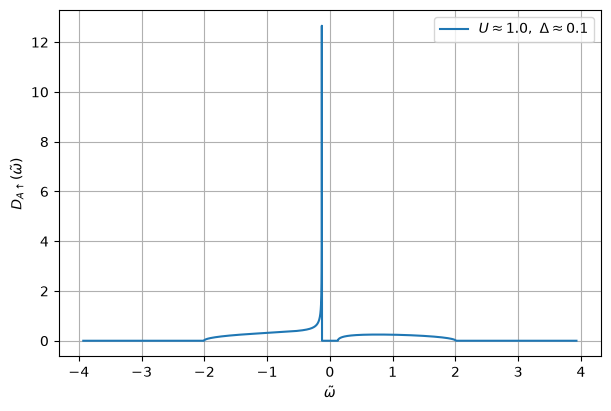

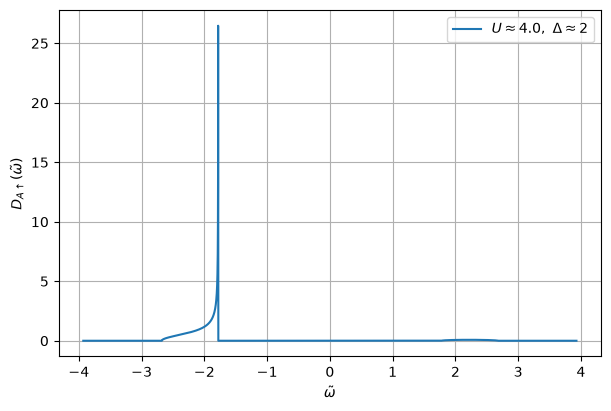

In [14]:
for U, Delta in zip(df_U_values["U_target"], df_U_values["Delta"]):
    omega_max = 1.05 * max(np.sqrt(Delta**2 + 4) for Delta in Delta_values)
    omega = np.linspace(-omega_max, omega_max, 5000)

    plt.figure(figsize=(7, 4.5))

    D = calculate_D_A_up(omega, Delta)

    plt.plot(
        omega,
        D,
        label=fr"$U \approx {U},\ \Delta \approx {Delta:.1g}$"
    )
    plt.xlabel(r"$\tilde{\omega}$")
    plt.ylabel(r"$D_{A\uparrow}(\tilde{\omega})$")
    plt.grid(True)
    plt.legend()
    plt.show()

In [15]:
def calculate_D(omega, Delta):
    D_up_positive_ommega = calculate_D_A_up(omega, Delta)
    D_up_negative_omega = calculate_D_A_up(-omega, Delta)
    D = D_up_positive_ommega + D_up_negative_omega
    return D

<Figure size 700x450 with 0 Axes>

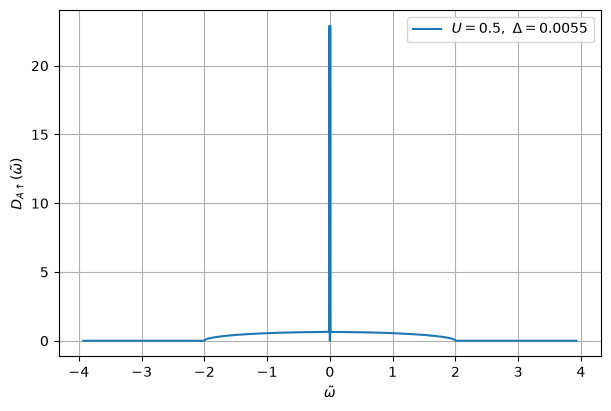

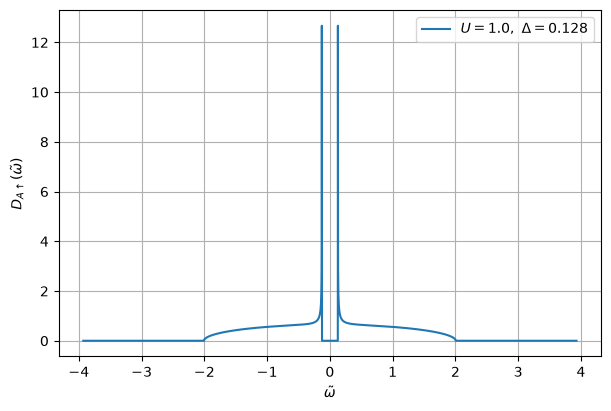

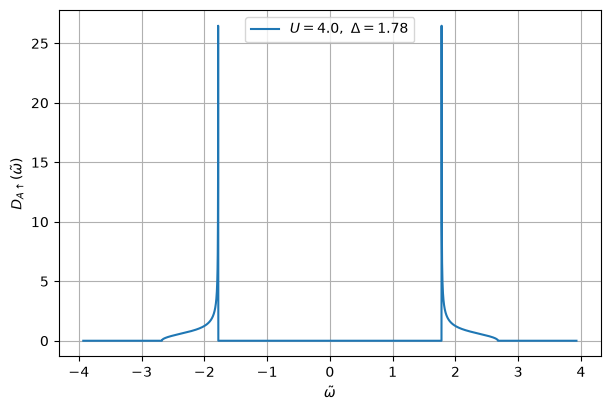

In [16]:
plt.figure(figsize=(7, 4.5))

for U, Delta in zip(df_U_values["U_target"], df_U_values["Delta"]):
    omega_max = 1.05 * max(np.sqrt(Delta**2 + 4) for Delta in Delta_values)
    omega = np.linspace(-omega_max, omega_max, 5000)

    plt.figure(figsize=(7, 4.5))

    D = calculate_D(omega, Delta)

    plt.plot(
        omega,
        D,
        label=fr"$U={U},\ \Delta={Delta:.3g}$"
    )
    plt.xlabel(r"$\tilde{\omega}$")
    plt.ylabel(r"$D_{A\uparrow}(\tilde{\omega})$")
    plt.grid(True)
    plt.legend()
    plt.show()